# Olist E-commerce Performance Analytics: Customer Behavior and Logistics Efficiency
### Introduction
This project investigates Olist's transactional ecosystem to identify revenue drivers and operational bottlenecks. By leveraging SQL for data aggregation and Python for statistical analysis, the study provides a comprehensive view of payment trends, customer loyalty, and regional performance.

### Executive Summary
1. **Payment Trends and Consumer Behavior**  
The analysis reveals that credit card transactions are the primary revenue driver, characterized by a high adoption of installment plans. This highlights the critical role of financial flexibility in the Brazilian e-commerce market and suggests that payment options directly influence purchasing power.

2. **Customer Retention and RFM Segmentation**  
RFM Analysis identifies a significant retention challenge. The customer base is heavily weighted toward New Customers and At Risk segments, with a remarkably small proportion of Champions. This indicates a high acquisition rate but a low long-term loyalty, signaling an urgent need for targeted retention strategies.

3. **Regional Logistics and Satisfaction Gaps**  
Statistical hypothesis testing (Welch’s T-test) confirms a substantial performance disparity between Sao Paulo (SP) and Rio de Janeiro (RJ). Sao Paulo significantly outperforms Rio de Janeiro in both delivery speed and customer review scores. To improve overall platform health, Olist should prioritize optimizing last-mile delivery and regional distribution in the RJ area to close the performance gap with the SP hub.

## 1. Payment Method Impact (Statistical Validation)

This analysis evaluates whether the chosen payment method significantly influences the Average Order Value (AOV). Specifically, credit card transactions are compared against boleto (bank slips) to validate if the availability of credit correlates with higher consumer spending.

### 1.1 Hypothesis Testing

- Null Hypothesis ($H_0$): There is no significant difference in the average payment value between Credit Card and Boleto users. ($\mu_{cc} = \mu_{bo}$)
- Alternative Hypothesis ($H_a$): There is a statistically significant difference in the average payment value between Credit Card and Boleto users. ($\mu_{cc} \neq \mu_{bo}$)
- Significance Level ($\alpha$): 0.05

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sqlite3

In [2]:
conn = sqlite3.connect(r'C:\Users\MSI\Desktop\Data Project\Olist\olist.db')

In [3]:
query = '''
SELECT  order_id, payment_type, payment_value
FROM order_payments
WHERE payment_type IN ('credit_card', 'boleto')
'''
df = pd.read_sql(query, conn)

conn.close()

In [4]:
df.head()

,order_id,payment_type,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,credit_card,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,credit_card,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,credit_card,65.71
3,ba78997921bbcdc1373bb41e913ab953,credit_card,107.78
4,42fdf880ba16b47b59251dd489d4441a,credit_card,128.45


### 1.2 Data Preprocessing & Outlier Removal
Preliminary analysis revealed that the payment data is heavily right-skewed with extreme outliers exceeding 13,000 BRL.


- Methodology: To improve statistical robustness while maintaining the integrity of high-value customer behavior, a 99th percentile clipping method was applied to the payment data.
- Rationale: Standard interquartile range (IQR) filtering was considered unsuitable for this dataset, as it would exclude a substantial number of legitimate, high-value transactions. Utilizing the 99th percentile allows for the retention of a large portion of the data, significantly reducing skewness while preserving crucial insights into high-spending customers.

In [5]:
df['payment_value'].skew()

np.float64(9.189510883208968)

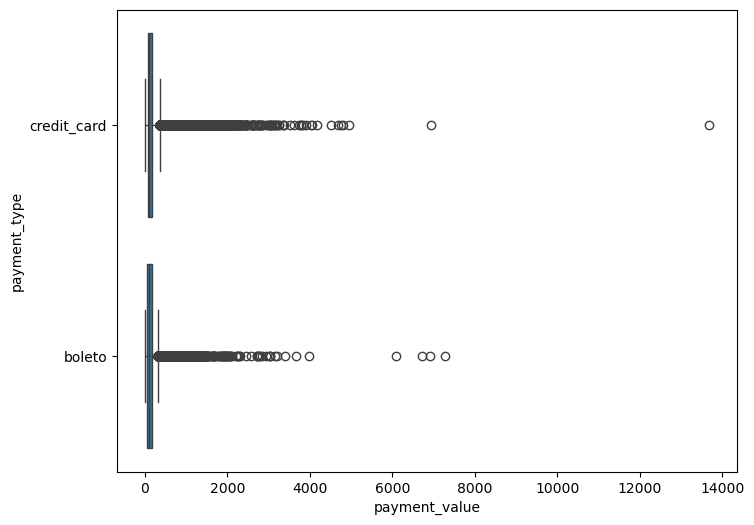

In [6]:
plt.figure(figsize = (8, 6))
sns.boxplot(data = df, x = 'payment_value', y = 'payment_type')
plt.show()

In [7]:
df_clean = df[df['payment_value'] <= df['payment_value'].quantile(0.99)]

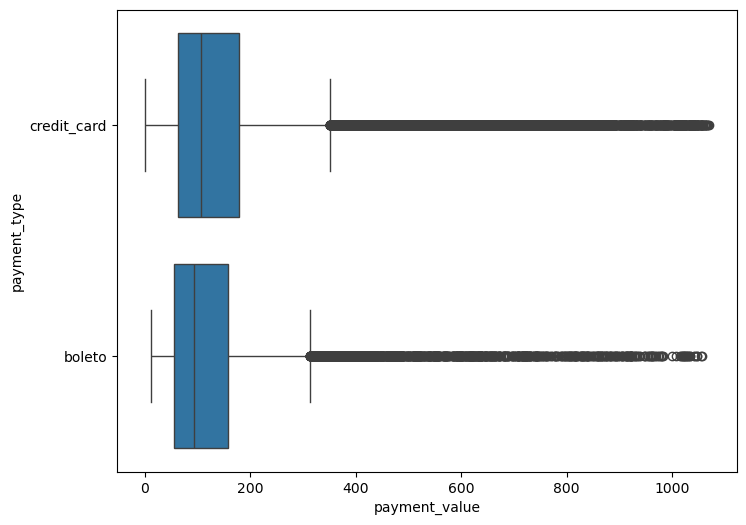

In [8]:
plt.figure(figsize = (8, 6))
sns.boxplot(data = df_clean, x = 'payment_value', y = 'payment_type')
plt.show()

### 1.3 Welch's T-Test Execution

In [9]:
cc = df_clean[df_clean['payment_type'] == 'credit_card']['payment_value']
bol = df_clean[df_clean['payment_type'] == 'boleto']['payment_value']

In [10]:
t_stat, p_val = stats.ttest_ind(cc, bol, equal_var = False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4g}")

T-statistic: 14.5781
P-value: 5.471e-48


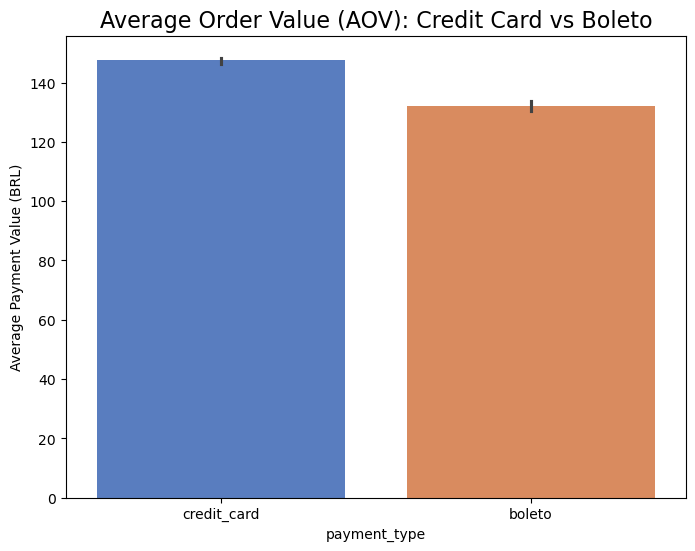

In [11]:
plt.figure(figsize=(8, 6))
sns.barplot(data = df_clean, x= 'payment_type', y = 'payment_value', hue = 'payment_type', palette = 'muted')
plt.title('Average Order Value (AOV): Credit Card vs Boleto', fontsize = 16)
plt.ylabel('Average Payment Value (BRL)')
plt.show()

In [12]:
summary = df_clean.groupby('payment_type')['payment_value'].agg(['mean', 'median', 'std', 'count'])
summary

,mean,median,std,count
payment_type,,,,
boleto,132.030757,93.13,129.483908,19627
credit_card,147.440362,105.87,141.389868,75986


### 1.4 Business Insights and Conclusion

**Statistical Outcome**:
- P-Value: $5.471 \times 10^{-48}$
- Decision: Since the p-value is significantly less than 0.05, the null hypothesis is rejected.

**Key Insights**
1. Credit card users exhibit a significantly higher average order value compared to boleto users.
2. The option to pay via installments likely encourages customers to purchase higher-priced items, whereas boleto is preferred for smaller, one-time payments.
3. Olist should continue to optimize the credit card installment experience and develop targeted promotions to maximize high-ticket sales.

## 2. Customer Segmentation using RFM Analysis

This section utilizes the RFM (Recency, Frequency, Monetary) framework to categorize the customer base according to purchasing behavior. This approach identifies high-value segments and highlights customers at risk of churning, providing actionable insights for personalized marketing strategies.


**RFM stands for**:
- Recency (R): Days since the last purchase.
- Frequency (F): Total number of completed purchases.
- Monetary (M): Total amount spent by the customer.

### 2.1 Data Extraction and Preparation (SQL)
The following SQL query extracts the raw metrics for each unique customer. A subquery is used to identify the latest transaction date in the entire dataset to calculate the relative Recency in days.

In [13]:
conn = sqlite3.connect(r'C:\Users\MSI\Desktop\Data Project\Olist\olist.db')

In [14]:
sql_query = '''
SELECT
    c.customer_unique_id,
    CAST(JULIANDAY((SELECT MAX(order_purchase_timestamp) FROM orders)) - JULIANDAY(MAX(o.order_purchase_timestamp)) AS INT) AS recency,
    COUNT(DISTINCT o.order_id) AS frequency,
    SUM(p.payment_value) AS monetary
FROM orders AS o
JOIN customers AS c ON o.customer_id = c.customer_id
JOIN order_payments AS p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
'''
rfm = pd.read_sql(sql_query, conn)

In [15]:
conn.close()

In [16]:
rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,585,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89


### 2.2 Scoring with Quintiles
Following data extraction, customers are ranked and assigned scores from 1 to 5 for each metric using the pd.qcut function. This method divides the dataset into five equal-sized groups (quintiles).

- Recency Scoring: Inverted labels are applied so that customers with the lowest recency (most recent) receive a score of 5.
- Monetary Scoring: Customers with the highest total spend receive a score of 5.
- Frequency Scoring: Due to the high volume of single-purchase customers, a binary-influenced logic is applied to distinguish repeat buyers.

In [17]:
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])
rfm['f_score'] = rfm['frequency'].apply(lambda x: 5 if x > 1 else 1)
rfm.head(10)

,customer_unique_id,recency,frequency,monetary,r_score,m_score,f_score
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,4,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,2,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,4,1
5,0004bd2a26a76fe21f786e4fbd80607f,194,1,166.98,4,4,1
6,00050ab1314c0e55a6ca13cf7181fecf,180,1,35.38,4,1,1
7,00053a61a98854899e70ed204dd4bafe,231,1,419.18,3,5,1
8,0005e1862207bf6ccc02e4228effd9a0,591,1,150.12,1,4,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,219,1,129.76,4,3,1


### 2.3 Segment Labeling and Visualization
Customer segments are defined by combining the R and F scores. This categorization simplifies complex behavioral data into distinct groups, such as Champions (high recency and high frequency) and At Risk (low recency).

In [18]:
def assign_segment(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    
    if r >= 4 and f == 5:
        return 'Champions'
    elif f == 5:
        return 'Loyal Customers'
    elif r >= 4:
        return 'New Customers'
    elif r <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

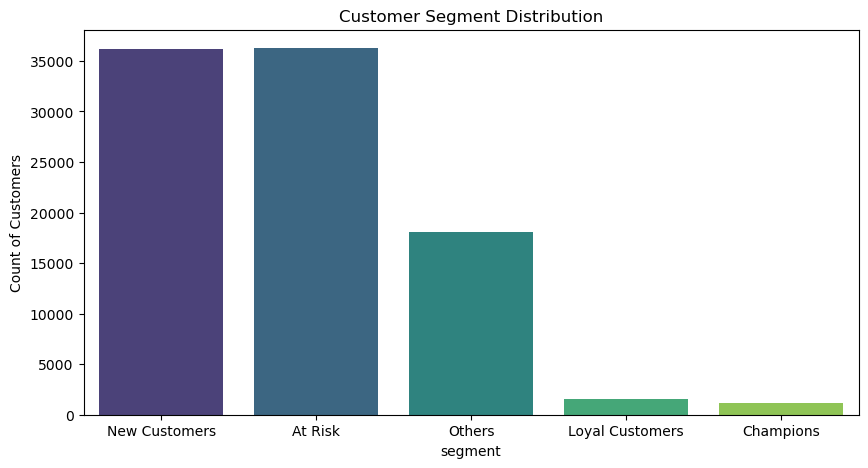

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(data = rfm, x = 'segment', hue = 'segment', palette = 'viridis')
plt.title('Customer Segment Distribution')
plt.ylabel('Count of Customers')
plt.show()

### 2.4 ฺBusiness Insights and Conclusion
**Segment Distribution Analysis**:  
The visualization reveals that New Customers and At Risk are the two largest segments in the database. This indicates a high rate of customer acquisition but a significant challenge in long-term retention.  

**Business Risk & Opportunity**:
- The small size of Champions and Loyal Customers suggests that most users tend to make a one-time purchase and do not return to the platform.
- A large portion of the customer base is currently in the At Risk category, meaning they haven't engaged with Olist for a long time. There is a critical need for re-engagement campaigns.  

**Actionable Recommendations**:
- Retention Program: Implement loyalty programs or personalized email marketing to transition New Customers into Loyal Customers.
- Win-back Strategy: Focus marketing spend on the At Risk segment with high Monetary (m_score) values to recover high-potential revenue.

## 3. Regional Performance Analysis by Retrospective A/B Testing (SP vs. RJ)
This section conducts a comparative analysis between the states of Sao Paulo (SP) and Rio de Janeiro (RJ). By treating these regions as two test groups, the analysis aims to determine if geographical location significantly impacts delivery efficiency and customer satisfaction.

**Key Metrics for Comparison**:
- Delivery Lead Time: The number of days from order purchase to actual delivery.
- Review Score: The satisfaction rating provided by the customer (1 to 5).

### 3.1 Data Retrieval and Preparation (SQL)
A SQL query is used to join the orders, customers, and reviews tables. The delivery lead time is calculated by subtracting the purchase timestamp from the delivery timestamp.

In [20]:
conn = sqlite3.connect(r'C:\Users\MSI\Desktop\Data Project\Olist\olist.db')

In [21]:
QUERY = ''' 
SELECT
    o.order_id,
    c.customer_state,
    CAST(JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_purchase_timestamp) AS INT) AS delivery_time,
    r.review_score
FROM orders AS o
JOIN customers AS c ON o.customer_id = c.customer_id
JOIN order_reviews AS r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND c.customer_state IN ('SP', 'RJ')
  AND o.order_delivered_customer_date IS NOT NULL
'''
df_ab = pd.read_sql(QUERY, conn)

In [22]:
conn.close()

In [23]:
df_ab.head()

,order_id,customer_state,delivery_time,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,SP,8,4
1,ad21c59c0840e6cb83a9ceb5573f8159,SP,2,5
2,6514b8ad8028c9f2cc2374ded245783f,RJ,9,5
3,e69bfb5eb88e0ed6a785585b27e16dbf,SP,18,5
4,e6ce16cb79ec1d90b1da9085a6118aeb,RJ,12,1


In [24]:
df_ab = df_ab[(df_ab['delivery_time'] >= 0) & (df_ab['delivery_time'] <= 60)]

### 3.2 Visual Comparison of Performance
Before conducting statistical tests, the distribution of delivery times is visualized to identify patterns between the two states.

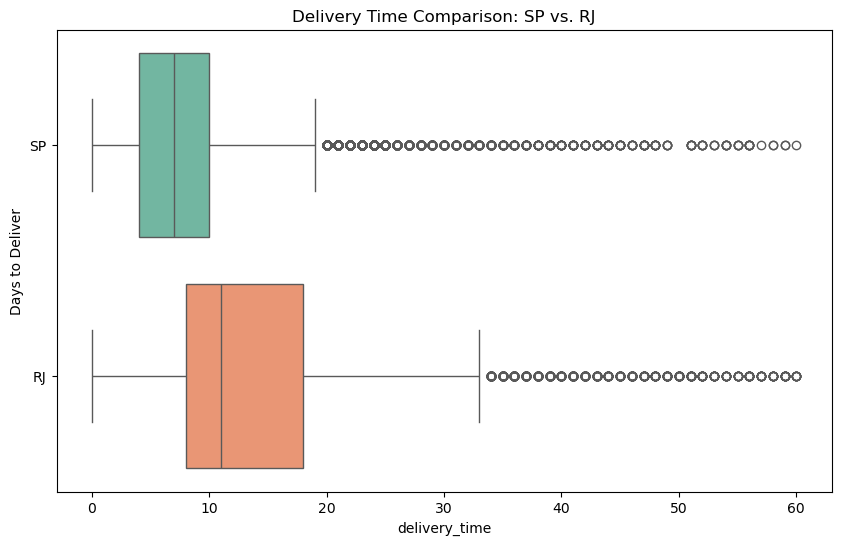

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(data = df_ab, x = 'delivery_time', y = 'customer_state', hue = 'customer_state', palette = 'Set2')
plt.title('Delivery Time Comparison: SP vs. RJ')
plt.ylabel('Days to Deliver')
plt.show()

### 3.3 Statistical Hypothesis Testing
To confirm if the observed differences are statistically significant, a Welch’s T-test is performed on both delivery time and review scores.
- Null Hypothesis ($H_0$): There is no significant difference in the average performance (delivery time and review scores) between SP and RJ. ($\mu_{SP} = \mu_{RJ}$)
- Alternative Hypothesis ($H_a$): There is a statistically significant difference in the average performance between SP and RJ. ($\mu_{SP} \neq \mu_{RJ}$)
- Significance Level ($\alpha$): 0.05

In [26]:
sp = df_ab[df_ab['customer_state'] == 'SP']
rj = df_ab[df_ab['customer_state'] == 'RJ']

In [27]:
t_stat_time, p_val_time = stats.ttest_ind(sp['delivery_time'], rj['delivery_time'], equal_var = False)
t_stat_score, p_val_score = stats.ttest_ind(sp['review_score'], rj['review_score'], equal_var=False)

In [28]:
print(f"Delivery Time P-Value: {p_val_time:.4g}")
print(f"Delivery Time T-statistic: {t_stat_time:.4g}")
print(f"Review Score P-Value: {p_val_score:.4g}")
print(f"Review Score T-statistic: {t_stat_score:.4g}")

Delivery Time P-Value: 0
Delivery Time T-statistic: -64.78
Review Score P-Value: 1.173e-76
Review Score T-statistic: 18.62


### 3.4 Business Insights and Conclusion
The statistical analysis confirms a significant performance gap between Sao Paulo (SP) and Rio de Janeiro (RJ) across both key metrics:
- **Logistics Efficiency**: With a T-statistic of $-64.78$ and $p < 0.001$, Sao Paulo achieves substantially faster delivery times. This highlights a major operational advantage in SP's infrastructure compared to RJ.
- **Customer Satisfaction**: The disparity in review scores is equally significant ($t = 18.62, p < 0.001$). The data proves that superior delivery speed in SP directly correlates with higher customer ratings.

**Strategic Takeaways**:
- The logistics delays in Rio de Janeiro are likely a primary driver for the high churn rate identified in Task 2. Improving regional delivery is essential for long-term loyalty.
- Olist should prioritize optimizing last-mile delivery and regional distribution in the RJ area to close the performance gap with the SP hub.
- Providing more transparent and conservative delivery estimates for RJ-based orders can help mitigate negative reviews caused by shipping delays.

### Export Dataframe to .CSV

In [29]:
rfm.to_csv('olist_rfm_segments.csv', index=False)
df_clean.to_csv('olist_payments_clean.csv', index=False)
df_ab.to_csv('olist_regional_performance.csv', index=False)